In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv    
import tensorflow as tf
import keras
import os
from keras.preprocessing.image import load_img
from PIL import Image




In [2]:
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
from keras.models import Sequential,Model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.utils import plot_model
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.initializers import random_uniform, glorot_uniform, constant, identity, orthogonal, zeros
from tensorflow.keras.layers import Add, GlobalMaxPooling2D, AveragePooling2D, GlobalAveragePooling2D, Input, Activation, ZeroPadding2D
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import datasets, layers, models

In [3]:
os.listdir(r"E:\Projects\Gender Detector\crop_part1") 

['100_1_0_20170110183726390.jpg.chip.jpg',
 '100_1_2_20170105174847679.jpg.chip.jpg',
 '101_1_2_20170105174739309.jpg.chip.jpg',
 '10_0_0_20161220222308131.jpg.chip.jpg',
 '10_0_0_20170103200329407.jpg.chip.jpg',
 '10_0_0_20170103200522151.jpg.chip.jpg',
 '10_0_0_20170103233459275.jpg.chip.jpg',
 '10_0_0_20170104013211746.jpg.chip.jpg',
 '10_0_0_20170110215927291.jpg.chip.jpg',
 '10_0_0_20170110220033115.jpg.chip.jpg',
 '10_0_0_20170110220111082.jpg.chip.jpg',
 '10_0_0_20170110220235233.jpg.chip.jpg',
 '10_0_0_20170110220251986.jpg.chip.jpg',
 '10_0_0_20170110220255346.jpg.chip.jpg',
 '10_0_0_20170110220316298.jpg.chip.jpg',
 '10_0_0_20170110220403810.jpg.chip.jpg',
 '10_0_0_20170110220447314.jpg.chip.jpg',
 '10_0_0_20170110220503946.jpg.chip.jpg',
 '10_0_0_20170110220514186.jpg.chip.jpg',
 '10_0_0_20170110220530650.jpg.chip.jpg',
 '10_0_0_20170110220539329.jpg.chip.jpg',
 '10_0_0_20170110220541850.jpg.chip.jpg',
 '10_0_0_20170110220546177.jpg.chip.jpg',
 '10_0_0_20170110220548521.jpg.

In [8]:
Task=r"e:\Projects\Gender Detector\UTKFace"
paths=[]
ages=[]
genders=[]
skipped=0

for file in os.listdir(Task):
    try:
        parts=file.split('_')
        age=parts[0]
        gender=parts[1]
        ages.append(age)
        genders.append(gender)
        paths.append(os.path.join(Task,file))
    except (ValueError, IndexError):
        skipped+=1
print("Loaded:",len(ages),"skipped:",skipped)


Loaded: 23708 skipped: 0


In [9]:
df=pd.DataFrame(list(zip(paths,ages,genders)),columns=['path','age','gender'])
df.info()
df.items

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23708 entries, 0 to 23707
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   path    23708 non-null  object
 1   age     23708 non-null  object
 2   gender  23708 non-null  object
dtypes: object(3)
memory usage: 555.8+ KB


<bound method DataFrame.items of                                                     path  age gender
0      e:\Projects\Gender Detector\UTKFace\100_0_0_20...  100      0
1      e:\Projects\Gender Detector\UTKFace\100_0_0_20...  100      0
2      e:\Projects\Gender Detector\UTKFace\100_1_0_20...  100      1
3      e:\Projects\Gender Detector\UTKFace\100_1_0_20...  100      1
4      e:\Projects\Gender Detector\UTKFace\100_1_0_20...  100      1
...                                                  ...  ...    ...
23703  e:\Projects\Gender Detector\UTKFace\9_1_3_2016...    9      1
23704  e:\Projects\Gender Detector\UTKFace\9_1_3_2017...    9      1
23705  e:\Projects\Gender Detector\UTKFace\9_1_4_2017...    9      1
23706  e:\Projects\Gender Detector\UTKFace\9_1_4_2017...    9      1
23707  e:\Projects\Gender Detector\UTKFace\9_1_4_2017...    9      1

[23708 rows x 3 columns]>

In [30]:
print(df["age"].min(), df["age"].max())
print(df["gender"].unique())
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["gender"] = pd.to_numeric(df["gender"], errors="coerce")

print(df[["age", "gender"]].dtypes)

1 116
['0' '1']
age       int64
gender    int64
dtype: object


In [31]:
from sklearn.model_selection import train_test_split
df["age"] = pd.to_numeric(df["age"], errors="coerce")



In [11]:
print(df["gender"].value_counts())

gender
0    12391
1    11317
Name: count, dtype: int64


In [32]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu126
CUDA available: True
CUDA version: 12.6
GPU: NVIDIA GeForce RTX 3050 A Laptop GPU


In [33]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 120]
labels = ["1-10", "11-20", "21-30", "31-40", "41-50", "51-60", "61-70", "71-80", "80+"]
df["age_bin"] = pd.cut(df["age"], bins=bins, labels=labels)
print("NaN bins:", df["age_bin"].isna().sum())   # should be 0

df["key"] = df["age_bin"].astype(str) + "_" + df["gender"].astype(str)
print(df["key"].value_counts().tail())            # smallest group must be >= 2

train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["key"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["key"], random_state=42
)

print(len(train_df), len(val_df), len(test_df))   # ~16.6k / 3.5k / 3.5k

print(pd.concat([
    train_df["age_bin"].value_counts(normalize=True).rename("train"),
    val_df["age_bin"].value_counts(normalize=True).rename("val"),
    test_df["age_bin"].value_counts(normalize=True).rename("test"),
], axis=1).round(3))

NaN bins: 0
key
71-80_0    422
61-70_1    396
80+_1      357
71-80_1    263
80+_0      183
Name: count, dtype: int64
16595 3556 3557
         train    val   test
age_bin                     
21-30    0.328  0.328  0.328
31-40    0.183  0.183  0.183
1-10     0.136  0.136  0.136
51-60    0.093  0.093  0.093
41-50    0.089  0.089  0.089
11-20    0.070  0.070  0.070
61-70    0.049  0.049  0.049
71-80    0.029  0.029  0.029
80+      0.023  0.023  0.022


In [34]:
import tensorflow as tf

IMG_SIZE = 128

def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

In [35]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH = 32

def make_example(path, age, gender):
    img = load_and_preprocess(path)
    return img, {
        "gender": tf.cast(gender, tf.float32),
        "age": tf.cast(age, tf.float32),
    }

def make_dataset(frame, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        frame["path"].values,
        frame["age"].values,
        frame["gender"].values,
    ))
    if training:
        ds = ds.shuffle(len(frame), seed=42)
    ds = ds.map(make_example, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

In [36]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    return x

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Shared body: 128 -> 64 -> 32 -> 16 -> 8
x = inputs
for f in (32, 64, 128, 256):
    x = conv_block(x, f)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)

# Gender head: binary classification
g = layers.Dense(64, activation="relu")(x)
gender_out = layers.Dense(1, activation="sigmoid", name="gender")(g)

# Age head: regression, linear output
a = layers.Dense(64, activation="relu")(x)
age_out = layers.Dense(1, name="age")(a)

model = models.Model(inputs, [gender_out, age_out])

model.compile(
    optimizer="adam",
    loss={"gender": "binary_crossentropy", "age": "huber"},
    loss_weights={"gender": 1.0, "age": 0.05},
    metrics={"gender": "accuracy", "age": "mae"},
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 64, 64,    │          0 │ re_lu_8[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │     18,432 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 32, 32,    │          0 │ re_lu_9[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │     73,728 │ max_pooling2d_9[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_10 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 16, 16,    │          0 │ re_lu_10[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 16, 16,    │    294,912 │ max_pooling2d_10… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_11 (ReLU)     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 8, 8, 256) │          0 │ re_lu_11[0][0]  

 Total params: 439,394 (1.68 MB)

 Trainable params: 438,434 (1.67 MB)

 Non-trainable params: 960 (3.75 KB)

In [37]:
model.fit(train_ds.take(20), validation_data=val_ds.take(5), epochs=1)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 294ms/step - age_loss: 27.4813 - age_mae: 27.9771 - gender_accuracy: 0.5734 - gender_loss: 0.7257 - loss: 2.0998 - val_age_loss: 32.9347 - val_age_mae: 33.4320 - val_gender_accuracy: 0.5250 - val_gender_loss: 0.7005 - val_loss: 2.3472


Epoch 1/15
519/519 ━━━━━━━━━━━━━━━━━━━━ 141s 272ms/step - age_loss: 13.4769 - age_mae: 13.9678 - gender_accuracy: 0.6688 - gender_loss: 0.6130 - loss: 1.2869 - val_age_loss: 16.3629 - val_age_mae: 16.8165 - val_gender_accuracy: 0.5931 - val_gender_loss: 0.6960 - val_loss: 1.5095 - learning_rate: 0.0010
Epoch 2/15
519/519 ━━━━━━━━━━━━━━━━━━━━ 137s 264ms/step - age_loss: 11.2577 - age_mae: 11.7489 - gender_accuracy: 0.7675 - gender_loss: 0.4852 - loss: 1.0483 - val_age_loss: 10.4886 - val_age_mae: 10.9921 - val_gender_accuracy: 0.7354 - val_gender_loss: 0.5430 - val_loss: 1.0695 - learning_rate: 0.0010
Epoch 3/15
519/519 ━━━━━━━━━━━━━━━━━━━━ 138s 265ms/step - age_loss: 10.0766 - age_mae: 10.5633 - gender_accuracy: 0.8200 - gender_loss: 0.3981 - loss: 0.9021 - val_age_loss: 10.4327 - val_age_mae: 10.9456 - val_gender_accuracy: 0.7478 - val_gender_loss: 0.5124 - val_loss: 1.0339 - learning_rate: 0.0010
Epoch 4/15
519/519 ━━━━━━━━━━━━━━━━━━━━ 137s 264ms/step - age_loss: 9.3153 - age_mae: 9.

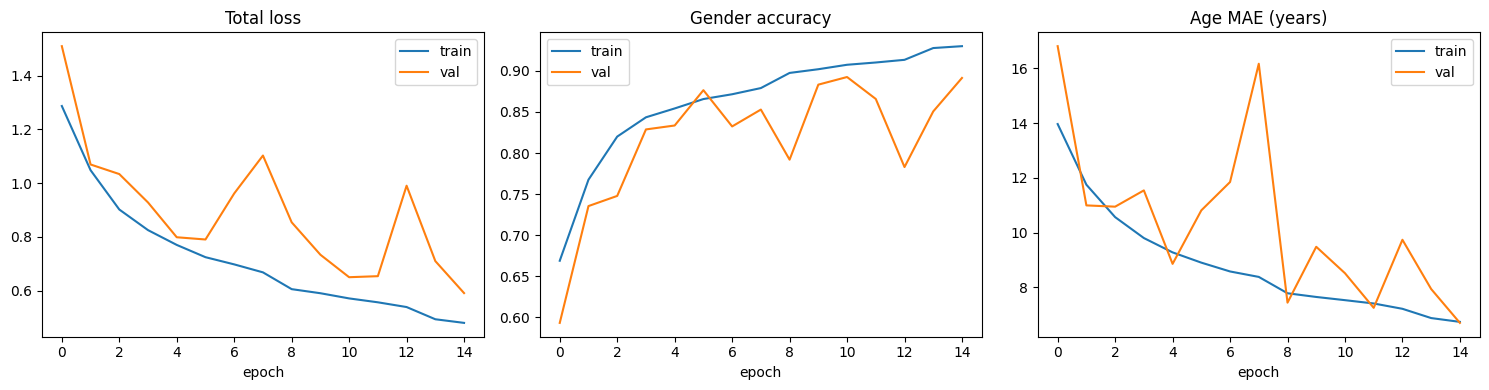

In [38]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
)

# Plot train vs validation
h = history.history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (key, title) in zip(axes, [
    ("loss", "Total loss"),
    ("gender_accuracy", "Gender accuracy"),
    ("age_mae", "Age MAE (years)"),
]):
    ax.plot(h[key], label="train")
    ax.plot(h["val_" + key], label="val")
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.legend()

plt.tight_layout()
plt.show()

In [40]:
from sklearn.metrics import confusion_matrix, classification_report

model = tf.keras.models.load_model("best_model.keras")

model.save("baseline_v1.keras")

# 1. Overall test metrics
print(model.evaluate(test_ds, return_dict=True))

# 2. Predictions (test_ds is not shuffled, so order matches test_df)
preds = model.predict(test_ds)
prob = preds[0].ravel()          # if preds is a dict: preds["gender"]
pred_age = preds[1].ravel()      # if preds is a dict: preds["age"]
assert len(prob) == len(test_df)

res = test_df.copy()
res["pred_age"] = pred_age
res["pred_gender"] = (prob > 0.5).astype(int)
res["abs_err"] = (res["pred_age"] - res["age"]).abs()
res["signed_err"] = res["pred_age"] - res["age"]   # negative = underpredicts
res["gender_correct"] = (res["pred_gender"] == res["gender"])

# 3. Per age bin
table = res.groupby("age_bin", observed=True).agg(
    n=("abs_err", "size"),
    mae=("abs_err", "mean"),
    bias=("signed_err", "mean"),
    gender_acc=("gender_correct", "mean"),
).round(2)
print(table)
print("Overall MAE:", res["abs_err"].mean().round(2))

# 4. Gender confusion matrix and report
print(confusion_matrix(res["gender"], res["pred_gender"]))
print(classification_report(res["gender"], res["pred_gender"],
                            target_names=["male", "female"]))


112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - age_loss: 6.2311 - age_mae: 6.6789 - gender_accuracy: 0.8904 - gender_loss: 0.2879 - loss: 0.5998
{'age_loss': 6.231109619140625, 'age_mae': 6.678913116455078, 'gender_accuracy': 0.8903570175170898, 'gender_loss': 0.2878834307193756, 'loss': 0.5997942090034485}
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step
            n    mae   bias  gender_acc
age_bin                                
1-10      483   3.55   2.38        0.68
11-20     250   7.00   5.50        0.89
21-30    1168   3.83   1.63        0.93
31-40     652   5.56  -3.13        0.94
41-50     315   8.92  -6.82        0.96
51-60     331  11.11  -9.11        0.92
61-70     176  13.06 -11.42        0.94
71-80     102  18.49 -17.31        0.90
80+        80  19.02 -17.94        0.61
Overall MAE: 6.68
[[1790   71]
 [ 319 1377]]
              precision    recall  f1-score   support

        male       0.85      0.96      0.90      1861
      female       0.95      0.81      0.88      1696

   

In [41]:
fem_err = res[(res.gender == 1) & (res.pred_gender == 0)]
print(len(fem_err))   # should be 319

by_bin = pd.DataFrame({
    "female_total": res[res.gender == 1].groupby("age_bin", observed=True).size(),
    "female_missed": fem_err.groupby("age_bin", observed=True).size(),
})
by_bin["miss_rate"] = (by_bin["female_missed"] / by_bin["female_total"]).round(2)
print(by_bin)

319
         female_total  female_missed  miss_rate
age_bin                                        
1-10              252            111       0.44
11-20             146             20       0.14
21-30             671             68       0.10
31-40             280             33       0.12
41-50              96             14       0.15
51-60             100             24       0.24
61-70              59             10       0.17
71-80              39              9       0.23
80+                53             30       0.57


In [42]:
val_prob = model.predict(val_ds)[0].ravel()   # use ["gender"] if preds is a dict
assert len(val_prob) == len(val_df)
y = val_df["gender"].values

rows = []
for t in np.arange(0.30, 0.71, 0.05):
    pred = (val_prob > t).astype(int)
    male_recall = ((pred == 0) & (y == 0)).sum() / (y == 0).sum()
    female_recall = ((pred == 1) & (y == 1)).sum() / (y == 1).sum()
    rows.append((round(t, 2), male_recall, female_recall, (pred == y).mean()))

print(pd.DataFrame(rows, columns=["thr", "male_rec", "female_rec", "acc"]).round(3))

112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step
    thr  male_rec  female_rec    acc
0  0.30     0.907       0.886  0.897
1  0.35     0.919       0.873  0.897
2  0.40     0.933       0.859  0.898
3  0.45     0.948       0.840  0.897
4  0.50     0.960       0.817  0.891
5  0.55     0.971       0.790  0.884
6  0.60     0.974       0.770  0.877
7  0.65     0.978       0.756  0.872
8  0.70     0.978       0.740  0.864


In [44]:
male_err = res[(res.gender == 0) & (res.pred_gender == 1)]
print(len(male_err))   # should be 71

by_bin_m = pd.DataFrame({
    "male_total": res[res.gender == 0].groupby("age_bin", observed=True).size(),
    "male_missed": male_err.groupby("age_bin", observed=True).size(),
}).fillna(0)
by_bin_m["miss_rate"] = (by_bin_m["male_missed"] / by_bin_m["male_total"]).round(2)

# Side by side with the female table from before
print(pd.concat([by_bin["miss_rate"].rename("girls_missed"),
                 by_bin_m["miss_rate"].rename("boys_missed")], axis=1))

71
         girls_missed  boys_missed
age_bin                           
1-10             0.44         0.18
11-20            0.14         0.07
21-30            0.10         0.02
31-40            0.12         0.02
41-50            0.15         0.00
51-60            0.24         0.01
61-70            0.17         0.00
71-80            0.23         0.02
80+              0.57         0.04


In [45]:
rows = []
for t in np.arange(0.10, 0.51, 0.025):
    pred = (val_prob > t).astype(int)
    m_rec = ((pred == 0) & (y == 0)).sum() / (y == 0).sum()
    f_rec = ((pred == 1) & (y == 1)).sum() / (y == 1).sum()
    rows.append((round(t, 3), m_rec, f_rec, abs(m_rec - f_rec), (pred == y).mean()))

sweep = pd.DataFrame(rows, columns=["thr", "male_rec", "female_rec", "gap", "acc"]).round(3)
print(sweep)
print("Best balance at threshold:", sweep.loc[sweep["gap"].idxmin(), "thr"])

      thr  male_rec  female_rec    gap    acc
0   0.100     0.846       0.944  0.098  0.893
1   0.125     0.855       0.938  0.082  0.895
2   0.150     0.861       0.928  0.067  0.893
3   0.175     0.873       0.920  0.047  0.895
4   0.200     0.880       0.916  0.036  0.897
5   0.225     0.886       0.909  0.023  0.897
6   0.250     0.892       0.903  0.011  0.897
7   0.275     0.900       0.892  0.008  0.896
8   0.300     0.907       0.886  0.020  0.897
9   0.325     0.911       0.882  0.029  0.897
10  0.350     0.919       0.873  0.045  0.897
11  0.375     0.926       0.869  0.057  0.899
12  0.400     0.933       0.859  0.074  0.898
13  0.425     0.941       0.853  0.088  0.899
14  0.450     0.948       0.840  0.108  0.897
15  0.475     0.954       0.832  0.122  0.895
16  0.500     0.960       0.817  0.143  0.891
Best balance at threshold: 0.275


In [47]:
from tensorflow.keras import layers, models

base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet"
)
base.trainable = False   # phase 1: train only the new heads

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = layers.Rescaling(2.0, offset=-1.0)(inputs)   # your 0-1 images -> -1..1, as MobileNetV2 expects
x = base(x, training=False)                      # keeps BatchNorm in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

g = layers.Dense(64, activation="relu")(x)
gender_out = layers.Dense(1, activation="sigmoid", name="gender")(g)
a = layers.Dense(64, activation="relu")(x)
age_out = layers.Dense(1, name="age")(a)

model_tl = models.Model(inputs, [gender_out, age_out])
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={"gender": "binary_crossentropy", "age": "huber"},
    loss_weights={"gender": 1.0, "age": 0.05},
    metrics={"gender": "accuracy", "age": "mae"},
)
model_tl.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer_5[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 4, 4,      │  2,257,984 │ rescaling[0][0]   │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │         65 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 1)         │         65 │ dense_11[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,438,594 (9.30 MB)

 Trainable params: 180,610 (705.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [48]:
def per_bin_report(model, ds, frame, thr=0.5):
    preds = model.predict(ds, verbose=0)
    prob = (preds["gender"] if isinstance(preds, dict) else preds[0]).ravel()
    age_p = (preds["age"] if isinstance(preds, dict) else preds[1]).ravel()
    assert len(prob) == len(frame)

    r = frame.copy()
    r["pred_age"] = age_p
    r["pred_gender"] = (prob > thr).astype(int)
    r["abs_err"] = (r["pred_age"] - r["age"]).abs()
    r["signed_err"] = r["pred_age"] - r["age"]
    r["ok"] = r["pred_gender"] == r["gender"]

    t = r.groupby("age_bin", observed=True).agg(
        n=("abs_err", "size"), mae=("abs_err", "mean"),
        bias=("signed_err", "mean"), gender_acc=("ok", "mean"),
    ).round(2)
    print(t)
    print("Overall MAE:", round(r["abs_err"].mean(), 2),
          "| gender acc:", round(r["ok"].mean(), 3))
    return r

In [49]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

model_tl.fit(train_ds.take(20), validation_data=val_ds.take(5), epochs=1)  # wiring test

cb = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ModelCheckpoint("mobilenet_phase1.keras", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6),
]
hist_tl = model_tl.fit(train_ds, validation_data=val_ds, epochs=6, callbacks=cb)

res_tl = per_bin_report(model_tl, val_ds, val_df)   # compare on validation, not test

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 182ms/step - age_loss: 26.1149 - age_mae: 26.6125 - gender_accuracy: 0.6078 - gender_loss: 0.7000 - loss: 2.0058 - val_age_loss: 19.9046 - val_age_mae: 20.3993 - val_gender_accuracy: 0.7688 - val_gender_loss: 0.5350 - val_loss: 1.5302
Epoch 1/6
519/519 ━━━━━━━━━━━━━━━━━━━━ 56s 107ms/step - age_loss: 10.1423 - age_mae: 10.6323 - gender_accuracy: 0.8013 - gender_loss: 0.4286 - loss: 0.9359 - val_age_loss: 8.2182 - val_age_mae: 8.7054 - val_gender_accuracy: 0.8420 - val_gender_loss: 0.3609 - val_loss: 0.7698 - learning_rate: 0.0010
Epoch 2/6
519/519 ━━━━━━━━━━━━━━━━━━━━ 76s 147ms/step - age_loss: 8.6795 - age_mae: 9.1597 - gender_accuracy: 0.8374 - gender_loss: 0.3644 - loss: 0.7983 - val_age_loss: 7.9227 - val_age_mae: 8.4189 - val_gender_accuracy: 0.8391 - val_gender_loss: 0.3407 - val_loss: 0.7360 - learning_rate: 0.0010
Epoch 3/6
519/519 ━━━━━━━━━━━━━━━━━━━━ 66s 127ms/step - age_loss: 8.2938 - age_mae: 8.7749 - gender_accuracy: 0.8516 - gender_loss: 0.336

In [50]:
res_tl1 = per_bin_report(model_tl, val_ds, val_df)

            n    mae   bias  gender_acc
age_bin                                
1-10      482   4.48   3.12        0.71
11-20     248   7.56   4.93        0.86
21-30    1167   4.21   0.42        0.88
31-40     650   6.82  -3.88        0.88
41-50     315  10.38  -8.32        0.93
51-60     332  14.48 -12.86        0.90
61-70     176  16.95 -15.59        0.91
71-80     104  19.56 -17.98        0.83
80+        82  19.90 -18.12        0.76
Overall MAE: 7.9 | gender acc: 0.858


In [51]:
# Reload the best phase 1 weights (restore_best_weights already did this, but be explicit)
model_tl = tf.keras.models.load_model("mobilenet_phase1.keras")

base = model_tl.get_layer("mobilenetv2_1.00_128")   # check the exact name in model_tl.summary()
base.trainable = True

# Freeze everything except the top ~30 layers
for layer in base.layers[:-30]:
    layer.trainable = False

# Keep BatchNorm frozen even in the unfrozen top section
for layer in base.layers[-30:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Trainable params:", sum(tf.size(w).numpy() for w in model_tl.trainable_weights))

# Recompile is required for the trainable change to take effect
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss={"gender": "binary_crossentropy", "age": "huber"},
    loss_weights={"gender": 1.0, "age": 0.05},
    metrics={"gender": "accuracy", "age": "mae"},
)

cb2 = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ModelCheckpoint("mobilenet_phase2.keras", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
]

hist_tl2 = model_tl.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=cb2)

res_tl2 = per_bin_report(model_tl, val_ds, val_df)

Trainable params: 1691330
Epoch 1/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 70s 125ms/step - age_loss: 7.4401 - age_mae: 7.9150 - gender_accuracy: 0.8904 - gender_loss: 0.2654 - loss: 0.6373 - val_age_loss: 7.0859 - val_age_mae: 7.5790 - val_gender_accuracy: 0.8690 - val_gender_loss: 0.3074 - val_loss: 0.6614 - learning_rate: 1.0000e-05
Epoch 2/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 68s 131ms/step - age_loss: 7.1144 - age_mae: 7.5854 - gender_accuracy: 0.9029 - gender_loss: 0.2374 - loss: 0.5931 - val_age_loss: 6.9010 - val_age_mae: 7.3824 - val_gender_accuracy: 0.8718 - val_gender_loss: 0.3051 - val_loss: 0.6490 - learning_rate: 1.0000e-05
Epoch 3/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 66s 127ms/step - age_loss: 6.8603 - age_mae: 7.3346 - gender_accuracy: 0.9124 - gender_loss: 0.2138 - loss: 0.5568 - val_age_loss: 6.8649 - val_age_mae: 7.3434 - val_gender_accuracy: 0.8737 - val_gender_loss: 0.3074 - val_loss: 0.6507 - learning_rate: 1.0000e-05
Epoch 4/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 68s 130ms/step - age_loss

In [52]:
baseline = tf.keras.models.load_model("baseline_v1.keras")
res_base = per_bin_report(baseline, val_ds, val_df)

            n    mae   bias  gender_acc
age_bin                                
1-10      482   3.74   2.18        0.71
11-20     248   6.79   5.09        0.89
21-30    1167   3.71   1.25        0.91
31-40     650   5.65  -2.90        0.93
41-50     315   9.13  -6.55        0.96
51-60     332  11.56  -8.83        0.93
61-70     176  13.15 -11.57        0.94
71-80     104  16.41 -14.75        0.91
80+        82  19.29 -18.97        0.73
Overall MAE: 6.69 | gender acc: 0.891


In [53]:
# Reload best phase 1 weights
model_tl = tf.keras.models.load_model("mobilenet_phase1.keras")

base = model_tl.get_layer("mobilenetv2_1.00_128")   # name from your summary()
base.trainable = True

# Freeze everything except the top ~30 layers
for layer in base.layers[:-30]:
    layer.trainable = False

# Keep BatchNorm frozen even in the unfrozen section
for layer in base.layers[-30:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Trainable params:", sum(tf.size(w).numpy() for w in model_tl.trainable_weights))

# Recompile so the trainable change takes effect
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss={"gender": "binary_crossentropy", "age": "huber"},
    loss_weights={"gender": 1.0, "age": 0.05},
    metrics={"gender": "accuracy", "age": "mae"},
)

cb2 = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ModelCheckpoint("mobilenet_phase2.keras", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
]

hist_tl2 = model_tl.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=cb2)

res_tl2 = per_bin_report(model_tl, val_ds, val_df)

Trainable params: 1691330
Epoch 1/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 65s 117ms/step - age_loss: 7.4378 - age_mae: 7.9140 - gender_accuracy: 0.8863 - gender_loss: 0.2678 - loss: 0.6397 - val_age_loss: 7.1686 - val_age_mae: 7.6646 - val_gender_accuracy: 0.8670 - val_gender_loss: 0.3050 - val_loss: 0.6633 - learning_rate: 1.0000e-05
Epoch 2/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 68s 130ms/step - age_loss: 7.0614 - age_mae: 7.5355 - gender_accuracy: 0.9024 - gender_loss: 0.2344 - loss: 0.5874 - val_age_loss: 6.8450 - val_age_mae: 7.3327 - val_gender_accuracy: 0.8726 - val_gender_loss: 0.3070 - val_loss: 0.6484 - learning_rate: 1.0000e-05
Epoch 3/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 65s 125ms/step - age_loss: 6.8743 - age_mae: 7.3488 - gender_accuracy: 0.9148 - gender_loss: 0.2105 - loss: 0.5541 - val_age_loss: 6.8241 - val_age_mae: 7.3049 - val_gender_accuracy: 0.8673 - val_gender_loss: 0.3234 - val_loss: 0.6620 - learning_rate: 1.0000e-05
Epoch 4/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 79s 151ms/step - age_loss

In [54]:
# Inverse frequency per bin, capped, then normalised so the mean weight is 1
counts = train_df["age_bin"].value_counts()
n_bins = counts.shape[0]
bin_w = (len(train_df) / (n_bins * counts)).clip(upper=5.0)

train_df = train_df.copy()
train_df["age_w"] = train_df["age_bin"].map(bin_w).astype(float)
train_df["age_w"] /= train_df["age_w"].mean()   # keeps loss scale comparable to before

print(train_df.groupby("age_bin", observed=True)["age_w"].first().round(2))

age_bin
1-10     0.82
11-20    1.59
21-30    0.34
31-40    0.61
41-50    1.25
51-60    1.19
61-70    2.25
71-80    3.85
80+      4.88
Name: age_w, dtype: float64


In [55]:
def make_example_w(path, age, gender, w):
    img = load_and_preprocess(path)
    labels = {"gender": tf.cast(gender, tf.float32), "age": tf.cast(age, tf.float32)}
    sw = {"gender": tf.constant(1.0), "age": tf.cast(w, tf.float32)}
    return img, labels, sw

train_ds_w = (
    tf.data.Dataset.from_tensor_slices((
        train_df["path"].values, train_df["age"].values,
        train_df["gender"].values, train_df["age_w"].values))
    .shuffle(len(train_df), seed=42)
    .map(make_example_w, num_parallel_calls=AUTOTUNE)
    .batch(BATCH).prefetch(AUTOTUNE)
)

for x, y, sw in train_ds_w.take(1):
    print(x.shape, sw["age"].numpy()[:8].round(2))

(32, 128, 128, 3) [0.82 0.34 0.34 0.34 0.61 0.61 0.34 0.34]


In [61]:
batch = next(iter(train_ds_w))

print("Type:", type(batch))
print("Length:", len(batch))
print("Batch:", batch)

Type: <class 'tuple'>
Length: 3
Batch: (<tf.Tensor: shape=(32, 128, 128, 3), dtype=float32, numpy=
array([[[[1.20588236e-01, 1.55882359e-01, 1.44117653e-01],
         [1.03626683e-01, 1.28994331e-01, 1.20538451e-01],
         [1.13315716e-01, 1.33658856e-01, 1.27408847e-01],
         ...,
         [8.08130383e-01, 8.04208815e-01, 7.33620584e-01],
         [8.27795625e-01, 8.23874056e-01, 7.53285825e-01],
         [8.25114906e-01, 8.21193337e-01, 7.50605106e-01]],

        [[9.13219973e-02, 1.26616120e-01, 1.14851408e-01],
         [8.42869207e-02, 1.09654568e-01, 1.01198681e-01],
         [9.80430469e-02, 1.18386179e-01, 1.12136185e-01],
         ...,
         [7.65697777e-01, 7.61776209e-01, 6.91187978e-01],
         [8.04193497e-01, 8.00271928e-01, 7.29683697e-01],
         [8.15490961e-01, 8.11569393e-01, 7.40981162e-01]],

        [[8.10431987e-02, 1.16337314e-01, 1.04572609e-01],
         [8.56579319e-02, 1.11025579e-01, 1.02569699e-01],
         [9.29457694e-02, 1.13288909e-01, 1

In [66]:
train_ds_w_fixed = train_ds_w.map(
    lambda x, weights, y: (x, y, weights)
)

batch = next(iter(train_ds_w_fixed))

print("Length:", len(batch))

print("Images:", batch[0].shape)
print("Labels:", batch[1].keys())
print("Weights:", batch[2].keys())





Length: 3
Images: (32, 128, 128, 3)
Labels: dict_keys(['gender', 'age'])
Weights: dict_keys(['gender', 'age'])


In [68]:
print(train_ds_w_fixed.element_spec)

(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), {'gender': TensorSpec(shape=(None,), dtype=tf.float32, name=None), 'age': TensorSpec(shape=(None,), dtype=tf.float32, name=None)}, {'gender': TensorSpec(shape=(None,), dtype=tf.float32, name=None), 'age': TensorSpec(shape=(None,), dtype=tf.float32, name=None)})


In [69]:
batch = next(iter(train_ds_w_fixed))

print("Type:", type(batch))
print("Length:", len(batch))

for i, item in enumerate(batch):
    print("\nITEM", i)
    print("Type:", type(item))

    if isinstance(item, dict):
        print("Keys:", item.keys())
        for k, v in item.items():
            print(k, v.shape, v.dtype)
    else:
        print("Shape:", item.shape)
        print("Dtype:", item.dtype)

Type: <class 'tuple'>
Length: 3

ITEM 0
Type: <class 'tensorflow.python.framework.ops.EagerTensor'>
Shape: (32, 128, 128, 3)
Dtype: <dtype: 'float32'>

ITEM 1
Type: <class 'dict'>
Keys: dict_keys(['gender', 'age'])
gender (32,) <dtype: 'float32'>
age (32,) <dtype: 'float32'>

ITEM 2
Type: <class 'dict'>
Keys: dict_keys(['gender', 'age'])
gender (32,) <dtype: 'float32'>
age (32,) <dtype: 'float32'>


In [70]:
x, y, sample_weight = next(iter(train_ds_w_fixed))

print("x:", x.shape)
print("y:", y.keys())
print("weights:", sample_weight.keys())

result = model_w.train_on_batch(
    x,
    y,
    sample_weight=sample_weight
)

print(result)

x: (32, 128, 128, 3)
y: dict_keys(['gender', 'age'])
weights: dict_keys(['gender', 'age'])
[]


In [71]:
x, y, sample_weight = next(iter(train_ds_w_fixed))

test_ds = tf.data.Dataset.from_tensors(
    (x, y, sample_weight)
)

In [73]:
print("Outputs:", model_w.output_names)
print("Loss:", model_w.loss)
print("Metrics:", model_w.metrics)
print("Run eagerly:", model_w.run_eagerly)

Outputs: ListWrapper(['gender', 'age'])
Loss: {'gender': 'binary_crossentropy', 'age': 'huber'}
Metrics: [<Mean name=loss>, <CompileMetrics name=compile_metrics>, <Mean name=gender_loss>, <Mean name=age_loss>]
Run eagerly: False


In [75]:
model_w.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss={
        "gender": tf.keras.losses.BinaryCrossentropy(),
        "age": tf.keras.losses.Huber()
    },
    loss_weights={
        "gender": 1.0,
        "age": 0.05
    },
    metrics={
        "gender": [tf.keras.metrics.BinaryAccuracy(name="accuracy")],
        "age": [tf.keras.metrics.MeanAbsoluteError(name="mae")]
    },
    run_eagerly=True
)

In [77]:
model_c = tf.keras.models.load_model("baseline_v1.keras")
model_c.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss={"gender": "binary_crossentropy", "age": "huber"},
    loss_weights={"gender": 1.0, "age": 0.05},
    metrics={"gender": "accuracy", "age": "mae"},
)

cb_c = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ModelCheckpoint("control_v1.keras", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

# train_ds is the ORIGINAL unweighted pipeline
hist_c = model_c.fit(train_ds, validation_data=val_ds, epochs=12, callbacks=cb_c)
res_c = per_bin_report(model_c, val_ds, val_df)

Epoch 1/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 140s 266ms/step - age_loss: 6.3415 - age_mae: 6.8173 - gender_accuracy: 0.9335 - gender_loss: 0.1582 - loss: 0.4753 - val_age_loss: 6.4614 - val_age_mae: 6.9310 - val_gender_accuracy: 0.9120 - val_gender_loss: 0.2217 - val_loss: 0.5450 - learning_rate: 3.0000e-04
Epoch 2/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 138s 265ms/step - age_loss: 6.1101 - age_mae: 6.5859 - gender_accuracy: 0.9391 - gender_loss: 0.1495 - loss: 0.4551 - val_age_loss: 8.1146 - val_age_mae: 8.6277 - val_gender_accuracy: 0.9061 - val_gender_loss: 0.2370 - val_loss: 0.6450 - learning_rate: 3.0000e-04
Epoch 3/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 138s 266ms/step - age_loss: 6.0933 - age_mae: 6.5706 - gender_accuracy: 0.9406 - gender_loss: 0.1456 - loss: 0.4503 - val_age_loss: 6.1107 - val_age_mae: 6.5543 - val_gender_accuracy: 0.8976 - val_gender_loss: 0.2815 - val_loss: 0.5825 - learning_rate: 3.0000e-04
Epoch 4/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 138s 266ms/step - age_loss: 5.8753 - age_mae: 6.

In [78]:
# Square-root of the capped inverse-frequency weights, renormalised to mean 1
train_df = train_df.copy()
train_df["age_w"] = np.sqrt(train_df["age_bin"].map(bin_w).astype(float))
train_df["age_w"] /= train_df["age_w"].mean()

print(train_df.groupby("age_bin", observed=True)["age_w"].first().round(2))

age_bin
1-10     0.98
11-20    1.36
21-30    0.63
31-40    0.84
41-50    1.21
51-60    1.18
61-70    1.62
71-80    2.12
80+      2.38
Name: age_w, dtype: float64


In [79]:
train_ds_sqrt = (
    tf.data.Dataset.from_tensor_slices((
        train_df["path"].values, train_df["age"].values,
        train_df["gender"].values, train_df["age_w"].values))
    .shuffle(len(train_df), seed=42)
    .map(make_example_w, num_parallel_calls=AUTOTUNE)
    .batch(BATCH).prefetch(AUTOTUNE)
)

In [80]:
model_s = tf.keras.models.load_model("baseline_v1.keras")
model_s.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss={"gender": "binary_crossentropy", "age": "huber"},
    loss_weights={"gender": 1.0, "age": 0.05},
    metrics={"gender": "accuracy", "age": "mae"},
)

cb_s = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ModelCheckpoint("weighted_sqrt.keras", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

hist_s = model_s.fit(train_ds_sqrt, validation_data=val_ds, epochs=12, callbacks=cb_s)
res_s = per_bin_report(model_s, val_ds, val_df)

Epoch 1/12


KeyError: 0

In [81]:
print(train_ds_sqrt.element_spec)   # compare with the line below
print(train_ds_w.element_spec)      # this one worked before
print(val_ds.element_spec)
print(model_s.output_names)

(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), {'gender': TensorSpec(shape=(None,), dtype=tf.float32, name=None), 'age': TensorSpec(shape=(None,), dtype=tf.float32, name=None)}, {'gender': TensorSpec(shape=(None,), dtype=tf.float32, name=None), 'age': TensorSpec(shape=(None,), dtype=tf.float32, name=None)})
(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), {'gender': TensorSpec(shape=(None,), dtype=tf.float32, name=None), 'age': TensorSpec(shape=(None,), dtype=tf.float32, name=None)}, {'gender': TensorSpec(shape=(None,), dtype=tf.float32, name=None), 'age': TensorSpec(shape=(None,), dtype=tf.float32, name=None)})
(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), {'gender': TensorSpec(shape=(None,), dtype=tf.float32, name=None), 'age': TensorSpec(shape=(None,), dtype=tf.float32, name=None)})
ListWrapper(['gender', 'age'])


In [82]:
for x, y, sw in train_ds_sqrt.take(1):
    print(model_s.evaluate(x, y, verbose=0))                         # no weights
    print(model_s.train_on_batch(x, y, sample_weight=sw))            # with weights

[0.3792838752269745, 0.17145782709121704, 4.156520843505859, 4.639459609985352, 0.90625]
[]


In [83]:
m_test = tf.keras.models.load_model("baseline_v1.keras")
m_test.compile(optimizer="adam",
               loss={"gender": "binary_crossentropy", "age": "huber"},
               loss_weights={"gender": 1.0, "age": 0.05},
               metrics={"gender": "accuracy", "age": "mae"})
m_test.fit(train_ds_w.take(5), validation_data=val_ds.take(2), epochs=1)

KeyError: 0

In [84]:
print(train_df["age_w"].isna().sum(), train_df["age_w"].describe())

0 count    16595.000000
mean         1.000000
std          0.405717
min          0.627764
25%          0.627764
50%          0.840877
75%          1.208639
max          2.383467
Name: age_w, dtype: float64


In [85]:
def make_example_w(path, age, gender, w):
    img = load_and_preprocess(path)
    labels = (tf.cast(gender, tf.float32), tf.cast(age, tf.float32))
    sw = (tf.constant(1.0), tf.cast(w, tf.float32))   # (gender weight, age weight)
    return img, labels, sw

In [86]:
train_ds_sqrt = (
    tf.data.Dataset.from_tensor_slices((
        train_df["path"].values, train_df["age"].values,
        train_df["gender"].values, train_df["age_w"].values))
    .shuffle(len(train_df), seed=42)
    .map(make_example_w, num_parallel_calls=AUTOTUNE)
    .batch(BATCH).prefetch(AUTOTUNE)
)

m_test.fit(train_ds_sqrt.take(5), validation_data=val_ds.take(2), epochs=1)

ValueError: Attr 'Toutput_types' of 'OptionalFromValue' Op passed list of length 0 less than minimum 1.

In [87]:
# bin_w is the capped inverse-frequency table from earlier
p = train_df["age_bin"].map(bin_w).astype(float) ** 0.5   # sqrt = softer scheme

train_rs = train_df.sample(n=len(train_df), replace=True,
                           weights=p, random_state=42).reset_index(drop=True)

print(train_rs["age_bin"].value_counts(normalize=True).round(3))
train_ds_rs = make_dataset(train_rs, training=True)   # your original, working pipeline

age_bin
21-30    0.212
31-40    0.151
1-10     0.130
41-50    0.110
51-60    0.109
11-20    0.093
61-70    0.081
71-80    0.062
80+      0.053
Name: proportion, dtype: float64


In [89]:
import keras
print(keras.__version__, tf.__version__)

model_s = tf.keras.models.load_model("baseline_v1.keras")
model_s.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss={"gender": "binary_crossentropy", "age": "huber"},
    loss_weights={"gender": 1.0, "age": 0.05},
    metrics={"gender": "accuracy", "age": "mae"},
)

# Plain, unweighted pipeline, 5 batches only
model_s.fit(train_ds.take(5), validation_data=val_ds.take(2), epochs=1)

3.14.1 2.21.0
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 346ms/step - age_loss: 5.9153 - age_mae: 6.4004 - gender_accuracy: 0.9250 - gender_loss: 0.1348 - loss: 0.4306 - val_age_loss: 6.4234 - val_age_mae: 6.8941 - val_gender_accuracy: 0.9062 - val_gender_loss: 0.1933 - val_loss: 0.5145


In [90]:
model_s.fit(train_ds_rs.take(5), validation_data=val_ds.take(2), epochs=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 307ms/step - age_loss: 7.9325 - age_mae: 8.4162 - gender_accuracy: 0.9625 - gender_loss: 0.1303 - loss: 0.5270 - val_age_loss: 6.7240 - val_age_mae: 7.1817 - val_gender_accuracy: 0.9531 - val_gender_loss: 0.1679 - val_loss: 0.5041


In [91]:
EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)

In [92]:
import numpy as np

def run_experiment(name, ds, epochs=12):
    m = tf.keras.models.load_model("baseline_v1.keras")
    m.compile(
        optimizer=tf.keras.optimizers.Adam(3e-4),
        loss={"gender": "binary_crossentropy", "age": "huber"},
        loss_weights={"gender": 1.0, "age": 0.05},
        metrics={"gender": "accuracy", "age": "mae"},
    )
    cb = [
        EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        ModelCheckpoint(f"{name}.keras", monitor="val_loss", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ]
    h = m.fit(ds, validation_data=val_ds, epochs=epochs, callbacks=cb)
    print(name, "best epoch:", int(np.argmin(h.history["val_loss"])) + 1,
          "| best val_loss:", round(min(h.history["val_loss"]), 4))
    return m, h, per_bin_report(m, val_ds, val_df)

# Check the resampling shares first
print(train_rs["age_bin"].value_counts(normalize=True).round(3))

# Run 1: control (plain data)
model_c, hist_c, res_c = run_experiment("control_v1", train_ds)

age_bin
21-30    0.212
31-40    0.151
1-10     0.130
41-50    0.110
51-60    0.109
11-20    0.093
61-70    0.081
71-80    0.062
80+      0.053
Name: proportion, dtype: float64
Epoch 1/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 158s 299ms/step - age_loss: 6.2863 - age_mae: 6.7592 - gender_accuracy: 0.9350 - gender_loss: 0.1607 - loss: 0.4750 - val_age_loss: 6.9317 - val_age_mae: 7.3516 - val_gender_accuracy: 0.8805 - val_gender_loss: 0.3233 - val_loss: 0.6662 - learning_rate: 3.0000e-04
Epoch 2/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 153s 295ms/step - age_loss: 6.1488 - age_mae: 6.6265 - gender_accuracy: 0.9346 - gender_loss: 0.1568 - loss: 0.4644 - val_age_loss: 6.2257 - val_age_mae: 6.6803 - val_gender_accuracy: 0.8898 - val_gender_loss: 0.3124 - val_loss: 0.6211 - learning_rate: 3.0000e-04
Epoch 3/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 153s 294ms/step - age_loss: 6.1423 - age_mae: 6.6169 - gender_accuracy: 0.9378 - gender_loss: 0.1518 - loss: 0.4588 - val_age_loss: 7.3972 - val_age_mae: 7.8708 - val_gender_ac

In [93]:
# Run 2: resampled data
model_s, hist_s, res_s = run_experiment("resampled_v1", train_ds_rs)

Epoch 1/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 154s 291ms/step - age_loss: 7.3626 - age_mae: 7.8402 - gender_accuracy: 0.9324 - gender_loss: 0.1629 - loss: 0.5310 - val_age_loss: 7.5506 - val_age_mae: 7.9787 - val_gender_accuracy: 0.9041 - val_gender_loss: 0.2419 - val_loss: 0.6183 - learning_rate: 3.0000e-04
Epoch 2/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 148s 285ms/step - age_loss: 7.0454 - age_mae: 7.5210 - gender_accuracy: 0.9425 - gender_loss: 0.1413 - loss: 0.4935 - val_age_loss: 6.1369 - val_age_mae: 6.5949 - val_gender_accuracy: 0.9066 - val_gender_loss: 0.2347 - val_loss: 0.5420 - learning_rate: 3.0000e-04
Epoch 3/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 140s 270ms/step - age_loss: 6.8881 - age_mae: 7.3650 - gender_accuracy: 0.9466 - gender_loss: 0.1323 - loss: 0.4767 - val_age_loss: 9.6195 - val_age_mae: 10.0252 - val_gender_accuracy: 0.8979 - val_gender_loss: 0.2819 - val_loss: 0.7607 - learning_rate: 3.0000e-04
Epoch 4/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 139s 268ms/step - age_loss: 6.7598 - age_mae: 7

In [95]:
h = hist_s.history
check = pd.DataFrame({
    "val_loss": h["val_loss"],
    "train_gender_acc": h["gender_accuracy"],
    "val_gender_acc": h["val_gender_accuracy"],
    "train_age_mae": h["age_mae"],
    "val_age_mae": h["val_age_mae"],
}).round(3)
check.index += 1   # epochs start at 1
print(check)

   val_loss  train_gender_acc  val_gender_acc  train_age_mae  val_age_mae
1     0.618             0.932           0.904          7.840        7.979
2     0.542             0.943           0.907          7.521        6.595
3     0.761             0.947           0.898          7.365       10.025
4     0.879             0.950           0.879          7.236       10.850
5     0.592             0.962           0.900          6.903        6.891
6     0.568             0.968           0.907          6.704        6.924
7     0.607             0.973           0.912          6.528        7.001
8     0.664             0.975           0.902          6.542        7.491


In [96]:
final = tf.keras.models.load_model("control_v1.keras")

preds = final.predict(val_ds, verbose=0)
val_prob = (preds["gender"] if isinstance(preds, dict) else preds[0]).ravel()
y = val_df["gender"].values
assert len(val_prob) == len(y)

rows = []
for t in np.arange(0.20, 0.71, 0.025):
    pred = (val_prob > t).astype(int)
    m_rec = ((pred == 0) & (y == 0)).sum() / (y == 0).sum()
    f_rec = ((pred == 1) & (y == 1)).sum() / (y == 1).sum()
    rows.append((round(t, 3), m_rec, f_rec, abs(m_rec - f_rec), (pred == y).mean()))

sweep = pd.DataFrame(rows, columns=["thr", "male_rec", "female_rec", "gap", "acc"]).round(3)
print(sweep.to_string())
print("Smallest recall gap at:", sweep.loc[sweep["gap"].idxmin(), "thr"])

      thr  male_rec  female_rec    gap    acc
0   0.200     0.861       0.956  0.095  0.906
1   0.225     0.865       0.954  0.089  0.907
2   0.250     0.869       0.949  0.081  0.907
3   0.275     0.873       0.946  0.073  0.908
4   0.300     0.876       0.942  0.066  0.907
5   0.325     0.880       0.937  0.057  0.907
6   0.350     0.885       0.934  0.049  0.908
7   0.375     0.889       0.932  0.043  0.909
8   0.400     0.891       0.928  0.037  0.909
9   0.425     0.897       0.924  0.027  0.910
10  0.450     0.900       0.922  0.021  0.911
11  0.475     0.904       0.920  0.016  0.911
12  0.500     0.910       0.916  0.006  0.913
13  0.525     0.913       0.912  0.000  0.913
14  0.550     0.917       0.908  0.008  0.913
15  0.575     0.919       0.906  0.013  0.913
16  0.600     0.922       0.901  0.022  0.912
17  0.625     0.927       0.896  0.031  0.912
18  0.650     0.929       0.888  0.041  0.909
19  0.675     0.931       0.884  0.047  0.909
20  0.700     0.934       0.879  0

In [99]:
THR = 0.5   # replace with your validation-chosen value
res_test = per_bin_report(final, test_ds, test_df, thr=THR)
print("Test MAE:", round(res_test["abs_err"].mean(), 2),
      "| gender acc:", round(res_test["ok"].mean(), 3))

AssertionError: 

In [102]:
print("test_df rows:", len(test_df))
print("test_ds samples:", sum(int(x.shape[0]) for x, *_ in test_ds))

preds = final.predict(test_ds, verbose=0)
print(type(preds))
if isinstance(preds, dict):
    print({k: v.shape for k, v in preds.items()})
else:
    print([p.shape for p in preds])

test_df rows: 3557
test_ds samples: 3557
<class 'list'>
[(3557, 1), (3557, 1)]


In [103]:
final = tf.keras.models.load_model("control_v1.keras")   # no evaluate() on this object

preds = final.predict(val_ds, verbose=0)
val_prob = preds[0].ravel()
y = val_df["gender"].values
print(len(val_prob), len(y))   # both should be 3556

rows = []
for t in np.arange(0.20, 0.71, 0.025):
    pred = (val_prob > t).astype(int)
    m_rec = ((pred == 0) & (y == 0)).sum() / (y == 0).sum()
    f_rec = ((pred == 1) & (y == 1)).sum() / (y == 1).sum()
    rows.append((round(t, 3), m_rec, f_rec, abs(m_rec - f_rec), (pred == y).mean()))

sweep = pd.DataFrame(rows, columns=["thr", "male_rec", "female_rec", "gap", "acc"]).round(3)
print(sweep.to_string())

3556 3556
      thr  male_rec  female_rec    gap    acc
0   0.200     0.861       0.956  0.095  0.906
1   0.225     0.865       0.954  0.089  0.907
2   0.250     0.869       0.949  0.081  0.907
3   0.275     0.873       0.946  0.073  0.908
4   0.300     0.876       0.942  0.066  0.907
5   0.325     0.880       0.937  0.057  0.907
6   0.350     0.885       0.934  0.049  0.908
7   0.375     0.889       0.932  0.043  0.909
8   0.400     0.891       0.928  0.037  0.909
9   0.425     0.897       0.924  0.027  0.910
10  0.450     0.900       0.922  0.021  0.911
11  0.475     0.904       0.920  0.016  0.911
12  0.500     0.910       0.916  0.006  0.913
13  0.525     0.913       0.912  0.000  0.913
14  0.550     0.917       0.908  0.008  0.913
15  0.575     0.919       0.906  0.013  0.913
16  0.600     0.922       0.901  0.022  0.912
17  0.625     0.927       0.896  0.031  0.912
18  0.650     0.929       0.888  0.041  0.909
19  0.675     0.931       0.884  0.047  0.909
20  0.700     0.934     

In [104]:
pd.set_option("display.max_rows", None)
res_test = per_bin_report(final, test_ds, test_df, thr=THR)


            n    mae  bias  gender_acc
age_bin                               
1-10      483   3.89  2.87        0.71
11-20     250   7.92  6.24        0.88
21-30    1168   4.81  3.08        0.96
31-40     652   6.19  0.20        0.96
41-50     315   7.91 -1.71        0.96
51-60     331   8.83 -2.17        0.95
61-70     176   9.79 -3.83        0.93
71-80     102  12.52 -8.54        0.87
80+        80  12.31 -9.22        0.76
Overall MAE: 6.44 | gender acc: 0.912


In [106]:
import os
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(res_test["gender"], res_test["pred_gender"]))
print(classification_report(res_test["gender"], res_test["pred_gender"],
                            target_names=["male", "female"]))

if not os.path.exists("final_model.keras"):
    final.save("final_model.keras")
print("saved:", os.path.exists("final_model.keras"))

[[1707  154]
 [ 159 1537]]
              precision    recall  f1-score   support

        male       0.91      0.92      0.92      1861
      female       0.91      0.91      0.91      1696

    accuracy                           0.91      3557
   macro avg       0.91      0.91      0.91      3557
weighted avg       0.91      0.91      0.91      3557

saved: True


In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices())
print("GPU:", tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPU: []


In [17]:
import cv2
import tensorflow as tf
from collections import deque

# =========================
# CONFIG
# =========================

MODEL_PATH = r"E:\Projects\Gender Detector\model\final_model.keras"
IMG_SIZE = 128
THR = 0.5

# =========================
# LOAD MODEL
# =========================

model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully!")

# =========================
# FACE DETECTOR
# =========================

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

if face_cascade.empty():
    raise RuntimeError("Failed to load Haar Cascade")

print("Face detector loaded successfully!")

# =========================
# WEBCAM
# =========================

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError("Could not open webcam")

age_hist = deque(maxlen=10)

# =========================
# MAIN LOOP
# =========================

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60, 60)
    )

    for (x, y, w, h) in faces:

        # Face crop
        face = frame[y:y+h, x:x+w]

        # Resize
        face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))

        # BGR → RGB
        face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

        # Normalize
        face = face.astype("float32") / 255.0

        # Add batch dimension
        face = tf.expand_dims(face, axis=0)

        # Prediction
        prediction = model.predict(face, verbose=0)

        gender_pred = prediction[0][0][0]
        age_pred = prediction[1][0][0]

        # Gender
        gender = "Female" if gender_pred >= THR else "Male"

        # Age
        age = int(round(float(age_pred)))

        # Display
        label = f"{gender}, Age: {age}"

        cv2.rectangle(
            frame,
            (x, y),
            (x+w, y+h),
            (0, 255, 0),
            2
        )

        cv2.putText(
            frame,
            label,
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

    cv2.imshow("Gender & Age Detector", frame)

    # Press Q to quit
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break


cap.release()
cv2.destroyAllWindows()

Model loaded successfully!
Face detector loaded successfully!


In [15]:
print("Gender output example:", gender_p[0][0])

Gender output example: 0.0022794844


In [2]:
import tensorflow as tf

model = tf.keras.models.load_model("final_model.keras")

print("Outputs:", model.output_names)
print("Output shapes:", model.output_shape)

Outputs: ListWrapper(['gender', 'age'])
Output shapes: [(None, 1), (None, 1)]


In [10]:
print(df["gender"].value_counts())

gender
0    12391
1    11317
Name: count, dtype: int64
